# 4 GRU模型

## 学习目标
- 了解GRU内部结构及计算公式。
- 掌握Pytorch中GRU工具的使用。
- 了解GRU的优势与缺点。

---

# 1 GRU介绍

GRU（Gated Recurrent Unit）也称门控循环单元结构，它也是传统RNN的变体，同LSTM一样能够有效捕捉长序列之间的语义关联。缓解梯度消失或爆炸现象。同时它的结构和计算要比LSTM更简单，它的核心结构可以分为两个部分去解析：

- 更新门
- 重置门

---

# 2 GRU的内部结构图

## 2.1 GRU结构分析

## 💡 第一性原理：为什么有了LSTM还需要GRU？

### LSTM是"大而全"，GRU是"少而精"

| 对比维度 | LSTM | GRU |
|---------|------|-----|
| 门数量 | 3个（遗忘+输入+输出） | 2个（重置+更新） |
| 细胞状态 | 有独立的C（传送带） | 没有！h 同时承担记忆和输出 |
| 参数量 | 较多 | 减少约 1/4 |
| 核心思路 | 两通路分离 | 一通路但用门精细控制 |

### 第一性洞察：GRU的简化逻辑

LSTM 有三个门，GRU 说：能不能合并？

- **重置门 r(t)** ≈ 融合了遗忘门的一半功能 —— "过去的信息有多少能进入当前计算？"
- **更新门 z(t)** ≈ 融合了遗忘门+输入门的另一半 —— "保留多少旧信息 vs 接收多少新信息？"

关键公式直觉：
$$h(t) = (1-z(t)) \odot h(t-1) + z(t) \odot \tilde{h}(t)$$

> - z(t)→1 时：h(t) ≈ 新候选 h̃(t) → 更新
> - z(t)→0 时：h(t) ≈ h(t-1) → 保留
> 
> **一个门同时控制了"保留旧"和"接收新"——这就是GRU比LSTM少一个门的原因。**

### 费曼类比：LSTM vs GRU

```
LSTM: 传送带(C) + 工人(h)，工人有3个按钮（忘/写/读）
GRU:  只有一个人，但他有2个控制器：
      - 重置门 = "我该忘掉多少以前的？"
      - 更新门 = "旧信息和新信息各占多少比例？"
      
结果：GRU 用更少的控制器实现了和LSTM差不多的效果。
就像自动挡 vs 手动挡——GRU 自动帮你省掉了一个开关。
```

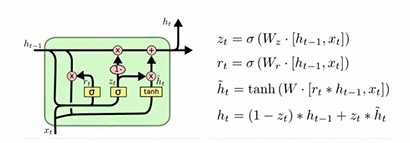

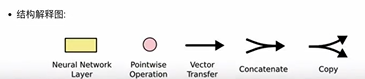

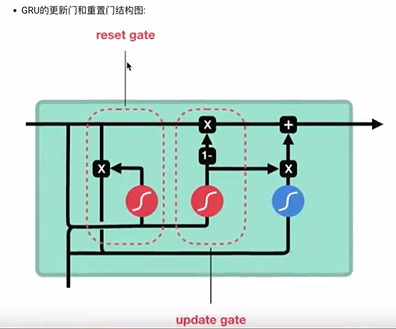

- 内部结构分析：
  - 和之前分析过的LSTM中的门控一样，首先计算更新门和重置门的门值，分别是z(t)和r(t)，计算方法就是使用X(t)与h(t-1)拼接进行线性变换，再经过sigmoid激活。之后重置门门值作用在h(t-1)上，代表控制上一时间步传来的信息有多少可以被利用。接着就是使用这个重置后的h(t-1)进行基本的RNN计算，即与x(t)拼接进行线性变换，经过tanh激活，得到新的h(t)。最后更新门的门值会作用在新的h(t)，而1-门值会作用在h(t-1)上，随后将两者的结果相加，得到最终的隐含状态输出h(t)，这个过程意味着更新门有能力保留之前的结果，当门值趋于1时，输出就是新的h(t)，而当门值趋于0时，输出就是上一时间步的h(t-1)。

## 2.2 Bi-GRU介绍

Bi-GRU与Bi-LSTM的逻辑相同，都是不改变其内部结构，而是将模型应用两次且方向不同，再将两次得到的LSTM结果进行拼接作为最终输出。具体参见上小节中的Bi-LSTM。

## 2.3 使用Pytorch构建GRU模型

- 位置：在torch.nn工具包之中，通过torch.nn.GRU可调用。
- nn.GRU类初始化主要参数解释：
  - input_size：输入张量x中特征维度的大小。
  - hidden_size：隐层张量h中特征维度的大小。
  - num_layers：隐含层的数量。
  - bidirectional: 是否选择使用双向LSTM, 如果为True, 则使用; 默认不使用.

- nn.GRU类实例化对象主要参数解释:
  - input: 输入张量x.
  - h0: 初始化的隐层张量h.

- nn.GRU使用示例:

In [ ]:
# ===== GRU vs LSTM 对比 =====
# GRU 没有独立的细胞状态C，只有隐层状态h
# 因此初始状态只需要 h0，不需要 c0
# 这是两者API上最大的区别！

import torch
import torch.nn as nn

# (input_size=5, hidden_size=6, num_layers=2)
rnn = nn.GRU(5, 6, 2)

# 输入: (seq_len=1, batch_size=3, input_size=5)
input = torch.randn(1, 3, 5)

# GRU只需要h0，不需要c0！
# (num_layers=2, batch_size=3, hidden_size=6)
h0 = torch.randn(2, 3, 6)

# GRU返回2个值（不是LSTM的3个！）
# output: 最后一层每个时间步的隐层输出  形状 (1, 3, 6)
# hn:     每一层的最后一个隐层状态      形状 (2, 3, 6)
output, hn = rnn(input, h0)
# 注意: LSTM 返回 output, (hn, cn)；GRU 返回 output, hn

## 2.4 GRU优缺点

- **GRU的优势**:
  - GRU和LSTM作用相同，在捕捉长序列语义关联时，能有效抑制梯度消失或爆炸，效果都优于传统RNN且计算复杂度相比LSTM要小。

- **GRU的缺点**:
  - GRU仍然不能完全解决梯度消失问题，同时其作用RNN的变体，有着RNN结构本身的一大弊端，即不可并行计算，这在数据量和模型体量逐步增大的未来，是RNN发展的关键瓶颈。